In [2]:
import pandas as pd
import ast
from collections import Counter

# 1. 데이터 불러오기
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')
silence_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_silence.csv')

# 2. 평균 가격 계산
graded_avg_price = graded_df['price'].mean()
silence_avg_price = silence_df['price'].mean()

print(f"### 평균 가격 비교 ###")
print(f"- 리뷰 10개 이상 (Graded): ${graded_avg_price:.2f}")
print(f"- 리뷰 0~9개 (Silence): ${silence_avg_price:.2f}")
print("-" * 30)

# 3. 장르 분석 함수 정의 (Indie 제외)
def get_top_genres(df, column_name, is_list_format=False, exclude='Indie'):
    all_genres = []
    for val in df[column_name].dropna():
        if is_list_format:
            # "['Genre1', 'Genre2']" 형태 파싱
            try:
                genres = ast.literal_eval(val)
            except:
                genres = [g.strip().replace("'", "") for g in val.replace('[', '').replace(']', '').split(',')]
        else:
            # "Genre1, Genre2" 형태 파싱
            genres = [g.strip() for g in val.split(',')]
        
        # 'Indie' 제외 및 정제
        filtered = [g for g in genres if g.lower() != exclude.lower()]
        all_genres.extend(filtered)
    
    return Counter(all_genres).most_common(10)

# 4. 장르 결과 출력
graded_top_10 = get_top_genres(graded_df, 'genres', is_list_format=False)
silence_top_10 = get_top_genres(silence_df, 'genres', is_list_format=True)

print("### 상위 10개 장르 (Indie 제외) ###")
print("\n[Graded Games - 리뷰 10개 이상]")
for genre, count in graded_top_10:
    print(f"- {genre}: {count}개")

print("\n[Silence Games - 리뷰 0~9개]")
for genre, count in silence_top_10:
    print(f"- {genre}: {count}개")

### 평균 가격 비교 ###
- 리뷰 10개 이상 (Graded): $8.84
- 리뷰 0~9개 (Silence): $5.63
------------------------------
### 상위 10개 장르 (Indie 제외) ###

[Graded Games - 리뷰 10개 이상]
- Adventure: 4745개
- Casual: 4060개
- Action: 4037개
- Simulation: 2453개
- RPG: 2161개
- Strategy: 1977개
- Sports: 332개
- Racing: 298개
- Massively Multiplayer: 113개
- 'Indie': 67개

[Silence Games - 리뷰 0~9개]
- Casual: 3589개
- Action: 3049개
- Adventure: 2865개
- Strategy: 1411개
- Simulation: 1236개
- RPG: 1134개
- Racing: 274개
- Sports: 249개


In [4]:
import pandas as pd
import json
from collections import Counter

# 1. 데이터 불러오기
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')
silence_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_silence.csv')

def get_top_tags(df, exclude='Indie'):
    tag_counter = Counter()
    
    # 'tags' 컬럼의 각 행을 순회
    for tag_str in df['tags'].dropna():
        try:
            # JSON 형태의 문자열을 딕셔너리로 변환
            # 예: '{"2D": 36, "RPG": 103}' -> {"2D": 36, "RPG": 103}
            tags_dict = json.loads(tag_str)
            
            for tag in tags_dict.keys():
                # 'Indie' 태그는 제외
                if tag.lower() != exclude.lower():
                    tag_counter[tag] += 1
        except (json.JSONDecodeError, TypeError):
            # 형식이 잘못된 데이터는 건너뜀
            continue
            
    return tag_counter.most_common(10)

# 2. 각 데이터셋에서 상위 10개 태그 추출
graded_top_tags = get_top_tags(graded_df)
silence_top_tags = get_top_tags(silence_df)

# 3. 결과 출력
print("### 상위 10개 태그 분석 (Indie 제외) ###")

print("\n[Graded Games - 리뷰 10개 이상]")
for i, (tag, count) in enumerate(graded_top_tags, 1):
    print(f"{i}. {tag}: {count}개 게임")

print("\n[Silence Games - 리뷰 0~9개]")
for i, (tag, count) in enumerate(silence_top_tags, 1):
    print(f"{i}. {tag}: {count}개 게임")

### 상위 10개 태그 분석 (Indie 제외) ###

[Graded Games - 리뷰 10개 이상]
1. Singleplayer: 7454개 게임
2. Adventure: 4640개 게임
3. Casual: 4172개 게임
4. Action: 4017개 게임
5. 2D: 3971개 게임
6. 3D: 3226개 게임
7. Atmospheric: 2885개 게임
8. Exploration: 2753개 게임
9. Simulation: 2480개 게임
10. Story Rich: 2410개 게임

[Silence Games - 리뷰 0~9개]
1. Singleplayer: 5302개 게임
2. Casual: 3522개 게임
3. 2D: 3119개 게임
4. Action: 3010개 게임
5. Adventure: 2720개 게임
6. 3D: 2402개 게임
7. Colorful: 1813개 게임
8. Puzzle: 1642개 게임
9. Pixel Graphics: 1630개 게임
10. Atmospheric: 1460개 게임


In [ ]:
import pandas as pd

# 1. 수정된 경로로 데이터 불러오기
graded_path = '../../../../data/preprocessed/steam_indie_games_graded.csv'
silence_path = '../../../../data/preprocessed/steam_indie_games_silence.csv'

graded_df = pd.read_csv(graded_path)
silence_df = pd.read_csv(silence_path)

# 2. Graded 데이터셋 만족도 통계 (기존 컬럼 활용)
graded_mean = graded_df['positive_rate'].mean()
graded_median = graded_df['positive_rate'].median()

# 3. Silence 데이터셋 만족도 계산 및 통계
# 리뷰가 0개인 게임은 분모가 0이 되므로, 리뷰가 1개 이상인 데이터만 필터링하여 계산합니다.
silence_valid = silence_df[silence_df['total_reviews'] > 0].copy()
silence_valid['positive_rate'] = (silence_valid['positive'] / silence_valid['total_reviews']) * 100

silence_mean = silence_valid['positive_rate'].mean()
silence_median = silence_valid['positive_rate'].median()

# 4. 결과 출력
print("### 만족도(긍정 리뷰 비율) 분석 결과 ###")
print(f"\n[Graded Games (리뷰 10개 이상)]")
print(f"- 평균(Mean): {graded_mean:.2f}%")
print(f"- 중앙값(Median): {graded_median:.2f}%")

print(f"\n[Silence Games (리뷰 0~9개)]")
print(f"- 평균(Mean): {silence_mean:.2f}%")
print(f"- 중앙값(Median): {silence_median:.2f}%")

### 만족도(긍정 리뷰 비율) 분석 결과 ###

[Graded Games (리뷰 10개 이상)]
- 평균(Mean): 84.14%
- 중앙값(Median): 88.33%

[Silence Games (리뷰 0~9개)]
- 평균(Mean): 79.72%
- 중앙값(Median): 100.00%
(참고: 리뷰가 0개인 138개의 게임은 통계에서 제외됨)


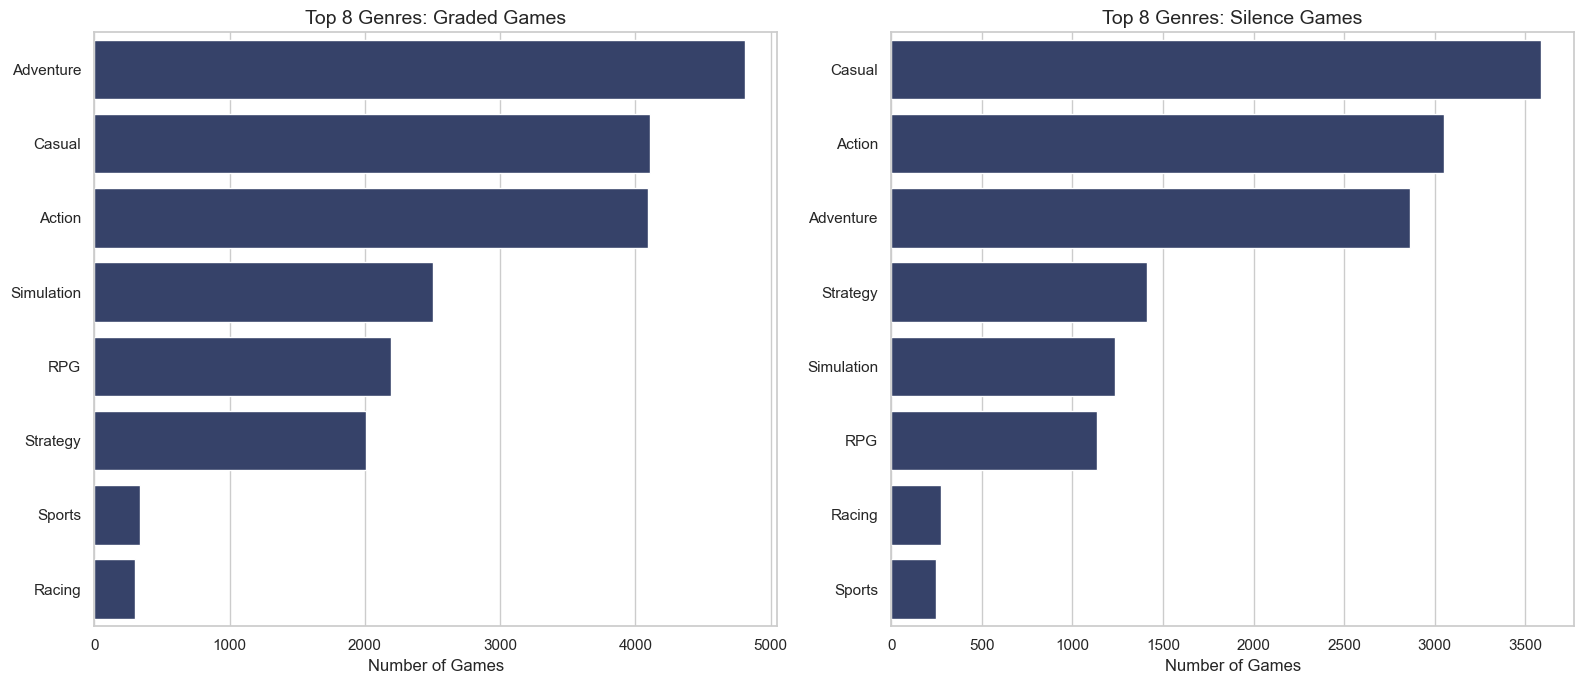

In [19]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기 (요청하신 경로 반영)
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')
silence_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_silence.csv')

# 2. 장르 분석 함수 (강력한 정제 로직 추가)
def get_genre_df(df, column_name, exclude='Indie'):
    all_genres = []
    for val in df[column_name].dropna():
        # 쉼표로 분리한 후, 각 항목에서 대괄호([])와 따옴표('")를 모두 제거합니다.
        items = [item.strip(" []'\"") for item in str(val).split(',')]
        
        # 'Indie'를 제외하고 빈 값이 아닌 것만 추가합니다.
        filtered = [i for i in items if i and i.lower() != exclude.lower()]
        all_genres.extend(filtered)
    
    counts = Counter(all_genres).most_common(8)
    return pd.DataFrame(counts, columns=['Genre', 'Count'])

# 데이터 가공
graded_top_10 = get_genre_df(graded_df, 'genres')
silence_top_10 = get_genre_df(silence_df, 'genres')

# 3. 시각화 설정 (색상: #2d3e71)
sns.set_theme(style="whitegrid")
requested_color = "#2d3e71" 

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graded Games 그래프
sns.barplot(x='Count', y='Genre', data=graded_top_10, ax=axes[0], color=requested_color)
axes[0].set_title('Top 8 Genres: Graded Games', fontsize=14)
axes[0].set_xlabel('Number of Games')
axes[0].set_ylabel('')

# Silence Games 그래프
sns.barplot(x='Count', y='Genre', data=silence_top_10, ax=axes[1], color=requested_color)
axes[1].set_title('Top 8 Genres: Silence Games', fontsize=14)
axes[1].set_xlabel('Number of Games')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

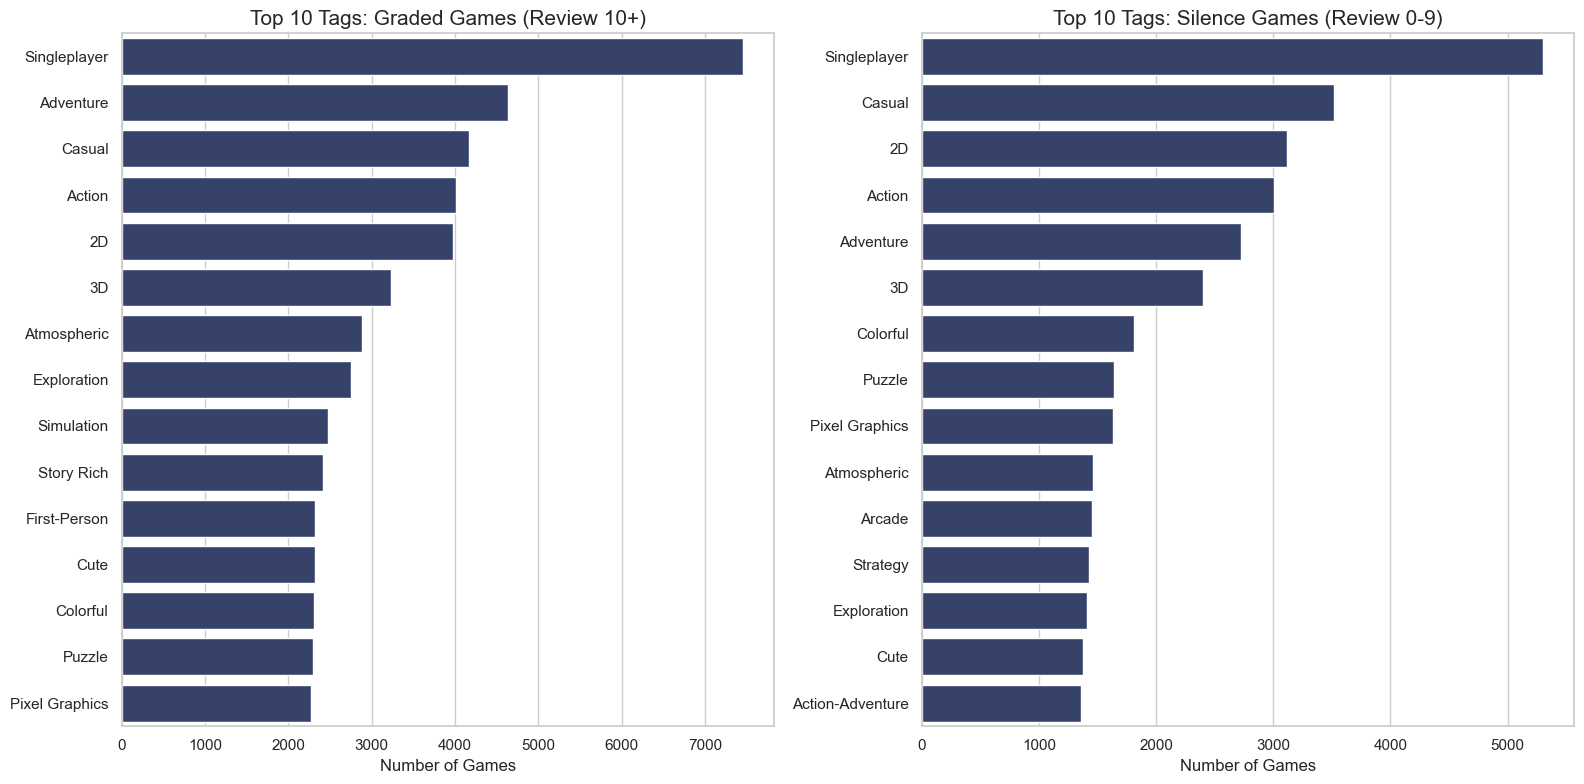

In [12]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. 데이터 불러오기 (요청하신 경로 반영)
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')
silence_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_silence.csv')

# 2. 태그 데이터 가공 함수 정의
def get_tag_df(df, exclude='Indie'):
    tag_counter = Counter()
    for tag_str in df['tags'].dropna():
        try:
            tags_dict = json.loads(tag_str)
            for tag in tags_dict.keys():
                if tag.lower() != exclude.lower():
                    tag_counter[tag] += 1
        except:
            continue
    
    # 상위 10개 추출 후 데이터프레임 변환
    counts = tag_counter.most_common(15)
    return pd.DataFrame(counts, columns=['Tag', 'Count'])

# 데이터 준비
graded_top_tags = get_tag_df(graded_df)
silence_top_tags = get_tag_df(silence_df)

# 3. 시각화 설정 (색상은 #2d3e71 사용)
sns.set_theme(style="whitegrid")
requested_color = "#2d3e71"

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Graded Games 태그 그래프
sns.barplot(x='Count', y='Tag', data=graded_top_tags, ax=axes[0], color=requested_color)
axes[0].set_title('Top 10 Tags: Graded Games (Review 10+)', fontsize=15)
axes[0].set_xlabel('Number of Games')
axes[0].set_ylabel('')

# Silence Games 태그 그래프
sns.barplot(x='Count', y='Tag', data=silence_top_tags, ax=axes[1], color=requested_color)
axes[1].set_title('Top 10 Tags: Silence Games (Review 0-9)', fontsize=15)
axes[1].set_xlabel('Number of Games')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

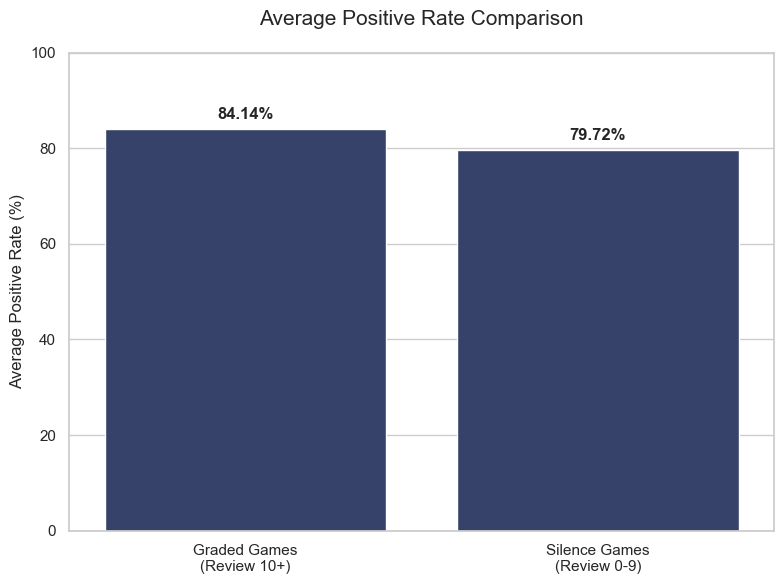

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수정된 경로로 데이터 불러오기
graded_path = '../../../../data/preprocessed/steam_indie_games_graded.csv'
silence_path = '../../../../data/preprocessed/steam_indie_games_silence.csv'

graded_df = pd.read_csv(graded_path)
silence_df = pd.read_csv(silence_path)

# 2. 평균 만족도 계산
# Graded
g_mean = graded_df['positive_rate'].mean()

# Silence (리뷰 1개 이상인 게임만 대상으로 계산)
silence_valid = silence_df[silence_df['total_reviews'] > 0].copy()
silence_valid['positive_rate'] = (silence_valid['positive'] / silence_valid['total_reviews']) * 100
s_mean = silence_valid['positive_rate'].mean()

# 3. 시각화 데이터 준비
plot_data = pd.DataFrame({
    'Group': ['Graded Games\n(Review 10+)', 'Silence Games\n(Review 0-9)'],
    'Average Positive Rate (%)': [g_mean, s_mean]
})

# 4. 시각화 설정 (색상: #2d3e71)
sns.set_theme(style="whitegrid")
requested_color = "#2d3e71"

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='Group', y='Average Positive Rate (%)', data=plot_data, color=requested_color)

# 제목 및 라벨 설정
ax.set_title('Average Positive Rate Comparison', fontsize=15, pad=20)
ax.set_ylabel('Average Positive Rate (%)')
ax.set_xlabel('')
ax.set_ylim(0, 100) # 퍼센트이므로 0~100 범위 설정

# 막대 위에 정확한 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()